In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv("hospital_data.csv")

In [72]:
df.columns

Index(['patient_id', 'patient_name', 'age', 'gender', 'department',
       'visit_date', 'blood_pressure', 'weight_kg', 'consultation_fee',
       'satisfaction_score', 'wait_time_min', 'city', 'insurance'],
      dtype='str')

In [73]:
df.dtypes

patient_id              int64
patient_name              str
age                   float64
gender                    str
department                str
visit_date                str
blood_pressure            str
weight_kg                 str
consultation_fee          str
satisfaction_score    float64
wait_time_min         float64
city                      str
insurance                 str
dtype: object

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          35 non-null     int64  
 1   patient_name        35 non-null     str    
 2   age                 29 non-null     float64
 3   gender              35 non-null     str    
 4   department          35 non-null     str    
 5   visit_date          35 non-null     str    
 6   blood_pressure      31 non-null     str    
 7   weight_kg           35 non-null     str    
 8   consultation_fee    35 non-null     str    
 9   satisfaction_score  28 non-null     float64
 10  wait_time_min       29 non-null     float64
 11  city                35 non-null     str    
 12  insurance           35 non-null     str    
dtypes: float64(3), int64(1), str(9)
memory usage: 3.7 KB


In [75]:
print(df[df["patient_name"].duplicated(keep=False)])

   patient_id  patient_name   age gender  department  visit_date  \
0         301  kwame asante  34.0   Male  Cardiology  2025-01-15   
5         303  kwame asante  34.0   Male  Cardiology  2025-01-15   

  blood_pressure weight_kg consultation_fee  satisfaction_score  \
0         120/80     75 kg          GHS 150                 8.0   
5         120/80     75 kg          GHS 150                 8.0   

   wait_time_min   city insurance  
0           25.0  Accra       Yes  
5           25.0  Accra       Yes  


In [76]:
df = df.drop_duplicates(subset="patient_name")
print(df["patient_name"].duplicated().sum())


0


In [77]:
df["patient_name"] = df["patient_name"].str.strip().str.replace(r"\s+", " ", regex=True).str.title()
print(df["patient_name"].tolist())

['Kwame Asante', 'Akosua Mensah', 'Yaw Boateng', 'Ama Owusu', 'Kofi Darko', 'Esi Adu', 'Nana Frimpong', 'Adwoa Sarpong', 'Fiifi Quaye', 'Bismark Ankrah', 'Akua Kyei', 'Kojo Poku', 'Serwa Tetteh', 'Kweku Antwi', 'Efua Mensah', 'Yaw Asare', 'Ama Darko', 'Kofi Owusu', 'Abena Quaye', 'Kwabena Ankrah', 'Nana Ama Boateng', 'Esi Frimpong', 'Bismark Asante', 'Akosua Kyei', 'Kojo Mensah', 'Kweku Adu', 'Adwoa Tetteh', 'Fiifi Poku', 'Yaw Sarpong', 'Akua Antwi', 'Kofi Asare', 'Esi Darko', 'Nana Quaye', 'Bismark Kyei']


In [78]:
df["age"]

0     34.0
1     28.0
2     45.0
3      NaN
4     67.0
6     23.0
7     56.0
8     41.0
9      NaN
10    38.0
11    29.0
12    52.0
13    19.0
14    73.0
15     NaN
16    31.0
17    44.0
18    26.0
19    60.0
20    35.0
21     NaN
22    48.0
23    22.0
24    55.0
25    39.0
26    27.0
27     NaN
28    50.0
29    33.0
30    42.0
31    25.0
32    58.0
33     NaN
34    36.0
Name: age, dtype: float64

In [79]:
median_age = df["age"].median()
print(median_age)

38.5


In [80]:
df["age"] = df["age"].fillna(median_age)
df["age"]

0     34.0
1     28.0
2     45.0
3     38.5
4     67.0
6     23.0
7     56.0
8     41.0
9     38.5
10    38.0
11    29.0
12    52.0
13    19.0
14    73.0
15    38.5
16    31.0
17    44.0
18    26.0
19    60.0
20    35.0
21    38.5
22    48.0
23    22.0
24    55.0
25    39.0
26    27.0
27    38.5
28    50.0
29    33.0
30    42.0
31    25.0
32    58.0
33    38.5
34    36.0
Name: age, dtype: float64

In [81]:
df["age"] = df["age"].astype(int)

In [82]:
# df.info()
# df.dtypes
df["age"].dtype

dtype('int64')

In [83]:
print(df["gender"].tolist())

['Male', 'f', 'MALE', 'Female', 'M', 'FEMALE', 'male', 'F', 'Male', 'female', 'FEMALE', 'M', 'f', 'MALE', 'Female', 'male', 'F', 'MALE', 'Female', 'm', 'FEMALE', 'Male', 'f', 'MALE', 'female', 'M', 'Female', 'male', 'F', 'MALE', 'female', 'm', 'F', 'Male']


In [84]:
df["gender"] = (df["gender"]
                .str.title()
                .replace({
                    "M": "Male",
                    "F": "Female"
                })
                )
print(df["gender"].tolist())

['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male']


In [85]:
df["department"] = df["department"].str.title()
print(df["department"].tolist())

['Cardiology', 'Pediatrics', 'Orthopedics', 'General', 'Cardiology', 'Pediatrics', 'General', 'Orthopedics', 'General', 'Cardiology', 'Pediatrics', 'Orthopedics', 'General', 'Cardiology', 'Pediatrics', 'Orthopedics', 'General', 'Cardiology', 'Pediatrics', 'Orthopedics', 'General', 'Cardiology', 'Pediatrics', 'Orthopedics', 'General', 'Cardiology', 'Pediatrics', 'Orthopedics', 'General', 'Cardiology', 'Pediatrics', 'Orthopedics', 'General', 'Cardiology']


In [86]:
df["visit_date"] = df["visit_date"].str.replace("/", "-")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["visit_date"] = df["visit_date"].fillna(pd.to_datetime("2025-01-01"))
df["visit_date"]

0    2025-01-15
1    2025-02-03
2    2025-01-22
3    2025-01-01
4    2025-02-18
6    2025-01-01
7    2025-03-05
8    2025-01-30
9    2025-01-01
10   2025-02-25
11   2025-01-01
12   2025-04-10
13   2025-01-01
14   2025-01-01
15   2025-03-15
16   2025-01-01
17   2025-04-22
18   2025-01-01
19   2025-01-01
20   2025-02-14
21   2025-01-01
22   2025-03-08
23   2025-01-01
24   2025-01-01
25   2025-01-19
26   2025-01-01
27   2025-02-07
28   2025-01-01
29   2025-01-01
30   2025-04-15
31   2025-01-01
32   2025-03-25
33   2025-01-01
34   2025-04-03
Name: visit_date, dtype: datetime64[us]

In [87]:
df["blood_pressure"] = df["blood_pressure"].fillna("120/80")
df[["systolic", "diastolic"]] = df["blood_pressure"].str.split("/", expand=True)
df["systolic"] = df["systolic"].astype(int)
df["diastolic"] = df["diastolic"].astype(int)

In [88]:
df["weight_kg"] = df["weight_kg"].str.strip().str.lower().str.replace("kg", "")
print(df["weight_kg"].tolist())

['75 ', '62', '88 ', '70 ', '95', '55 ', '82', '68 ', '90 ', '73', '58 ', '85 ', '50', '92 ', '65 ', '78', '72 ', '60 ', '88', '70 ', '85 ', '76', '55 ', '90 ', '68', '60 ', '72 ', '53', '87 ', '71 ', '57', '84 ', '63 ', '76']


In [89]:
df["weight_kg"] = df["weight_kg"].astype(float)

In [90]:
df["consultation_fee"] = df["consultation_fee"].str.strip().str.replace("GHS", "").astype(float)
print(df["consultation_fee"].tolist())

[150.0, 100.0, 200.0, 150.0, 250.0, 100.0, 150.0, 200.0, 250.0, 150.0, 100.0, 200.0, 150.0, 250.0, 100.0, 200.0, 150.0, 250.0, 100.0, 200.0, 150.0, 250.0, 100.0, 200.0, 150.0, 250.0, 100.0, 200.0, 150.0, 250.0, 100.0, 200.0, 150.0, 250.0]


In [91]:
print(df["consultation_fee"].dtypes)

float64


In [92]:
median_score = df["satisfaction_score"].median()
df["satisfaction_score"] = df["satisfaction_score"].fillna(median_score).astype(int)
df["satisfaction_score"]


0      8
1      9
2      8
3      7
4      6
6     10
7      8
8      8
9      7
10     9
11     8
12     6
13     9
14     5
15     8
16     8
17     7
18     9
19     6
20     8
21     8
22     7
23     9
24     5
25     8
26     8
27     9
28     6
29     7
30     8
31     8
32     7
33     9
34     6
Name: satisfaction_score, dtype: int64

In [93]:
median_min = df["wait_time_min"].median()
df["wait_time_min"] = df["wait_time_min"].fillna(median_min).astype(int)
df["wait_time_min"]


0     25
1     15
2     45
3     32
4     60
6     10
7     50
8     30
9     32
10    35
11    20
12    55
13    12
14    70
15    32
16    28
17    40
18    18
19    65
20    32
21    32
22    42
23    22
24    58
25    30
26    15
27    32
28    48
29    25
30    38
31    20
32    52
33    32
34    33
Name: wait_time_min, dtype: int64

In [94]:
df["month"] = df["visit_date"].dt.month_name()
df

,patient_id,patient_name,age,gender,department,visit_date,blood_pressure,weight_kg,consultation_fee,satisfaction_score,wait_time_min,city,insurance,systolic,diastolic,month
0,301,Kwame Asante,34,Male,Cardiology,2025-01-15,120/80,75.0,150.0,8,25,Accra,Yes,120,80,January
1,302,Akosua Mensah,28,Female,Pediatrics,2025-02-03,110/70,62.0,100.0,9,15,kumasi,no,110,70,February
2,303,Yaw Boateng,45,Male,Orthopedics,2025-01-22,140/90,88.0,200.0,8,45,TEMA,YES,140,90,January
3,304,Ama Owusu,38,Female,General,2025-01-01,130/85,70.0,150.0,7,32,Accra,No,130,85,January
4,305,Kofi Darko,67,Male,Cardiology,2025-02-18,180/110,95.0,250.0,6,60,Takoradi,yes,180,110,February
6,306,Esi Adu,23,Female,Pediatrics,2025-01-01,95/60,55.0,100.0,10,10,KUMASI,NO,95,60,January
7,307,Nana Frimpong,56,Male,General,2025-03-05,150/95,82.0,150.0,8,50,tema,yes,150,95,March
8,308,Adwoa Sarpong,41,Female,Orthopedics,2025-01-30,125/82,68.0,200.0,8,30,accra,No,125,82,January
9,309,Fiifi Quaye,38,Male,General,2025-01-01,120/80,90.0,250.0,7,32,Takoradi,YES,120,80,January
10,310,Bismark Ankrah,38,Female,Cardiology,2025-02-25,135/88,73.0,150.0,9,35,Kumasi,no,135,88,February


In [95]:
df["city"] = df["city"].str.title()
print(df["city"].tolist())

['Accra', 'Kumasi', 'Tema', 'Accra', 'Takoradi', 'Kumasi', 'Tema', 'Accra', 'Takoradi', 'Kumasi', 'Accra', 'Tema', 'Kumasi', 'Accra', 'Takoradi', 'Accra', 'Kumasi', 'Tema', 'Accra', 'Takoradi', 'Accra', 'Kumasi', 'Tema', 'Accra', 'Kumasi', 'Takoradi', 'Accra', 'Kumasi', 'Tema', 'Accra', 'Takoradi', 'Accra', 'Kumasi', 'Tema']


In [96]:
df["insurance"] = df["insurance"].str.title()

In [97]:
df.to_csv("clean_data.csv", index=False)

In [98]:
df = pd.read_csv("clean_data.csv")

In [99]:
avg_fee = df.groupby("department")["consultation_fee"].mean()
highest = avg_fee.idxmax()


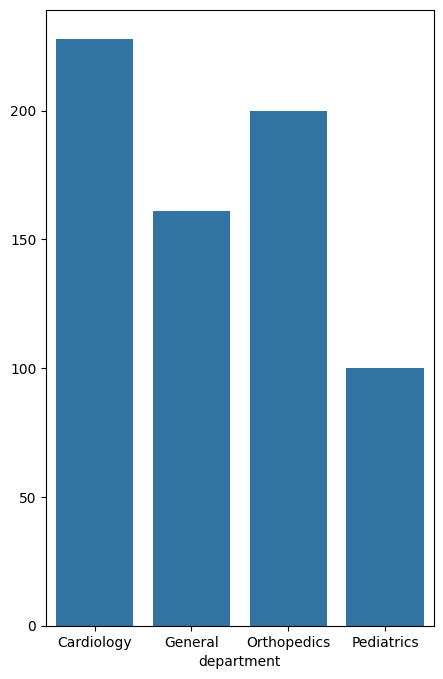

In [100]:
# Q1. Which department has the highest average consultation fee?
# Create a bar plot showing the average consultation fee for each department.
plt.figure(figsize= (5,8))
sns.barplot(x=avg_fee.index, y=avg_fee.values)
plt.show()

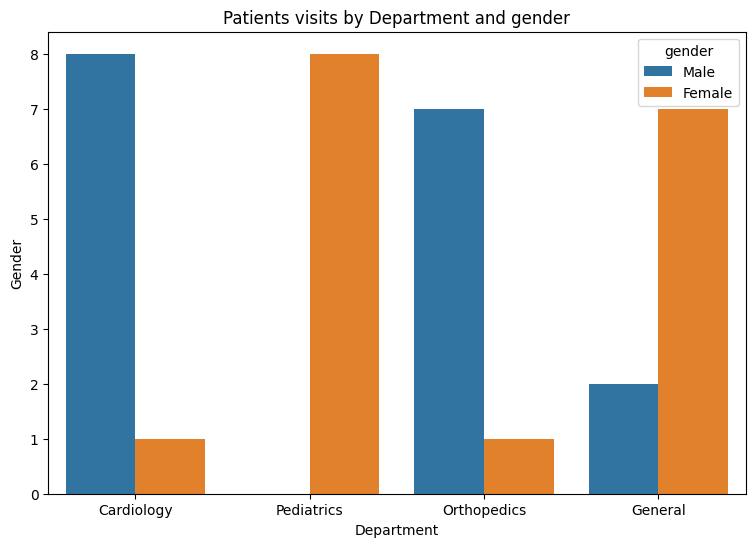

In [101]:
# Q2. How many patients visited each department, and how does this vary by gender?
# Create a count plot with gender as the hue to compare patient visits across departments.
plt.figure(figsize= (9,6))
sns.countplot(data=df, x="department", hue="gender")
plt.title("Patients visits by Department and gender")
plt.xlabel("Department")
plt.ylabel("Gender")
plt.show()

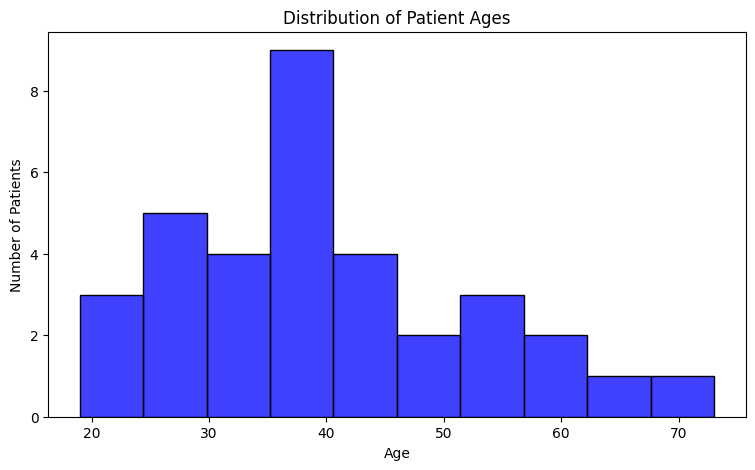

In [102]:
# What does the distribution of patient ages look like? Are most patients young, middle-aged, or older?
# Create a histogram to show the distribution of patient ages.
plt.figure(figsize= (9,5))
sns.histplot(data=df, x="age", bins=10, color="blue")
plt.title("Distribution of Patient Ages")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

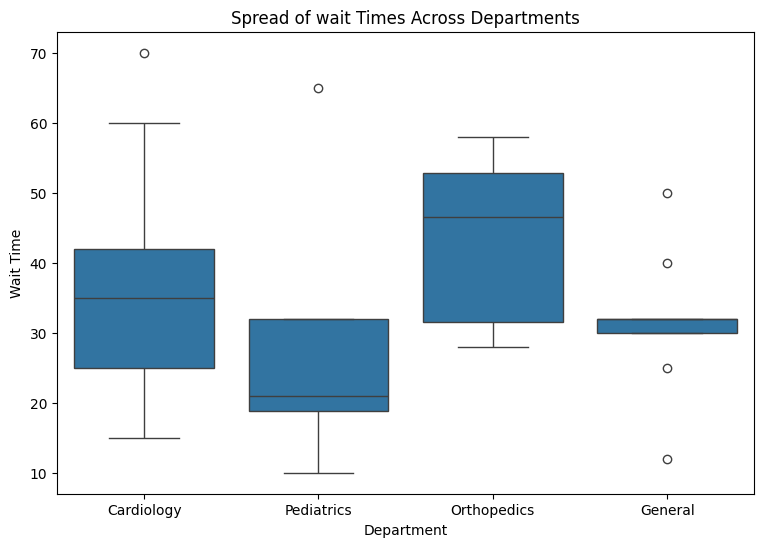

In [103]:
# 4.How does the spread of wait times differ across the six departments, and which department appears to have outliers?
# Create a box plot comparing wait times across departments.
plt.figure(figsize= (9,6))
sns.boxplot(data=df, x="department", y="wait_time_min")
plt.title("Spread of wait Times Across Departments")
plt.xlabel("Department")
plt.ylabel("Wait Time")
plt.show()

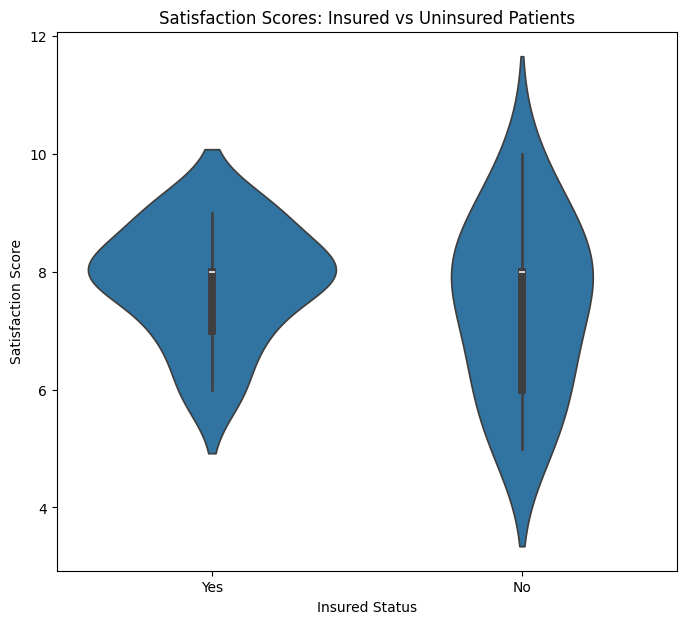

In [104]:
# Q5. How do satisfaction score distributions differ between insured and uninsured patients?
# Create a violin plot to compare the shape of the distributions.
plt.figure(figsize= (8,7))
sns.violinplot(data=df, x="insurance", y="satisfaction_score")
plt.title("Satisfaction Scores: Insured vs Uninsured Patients")
plt.xlabel("Insured Status")
plt.ylabel("Satisfaction Score")
plt.show()

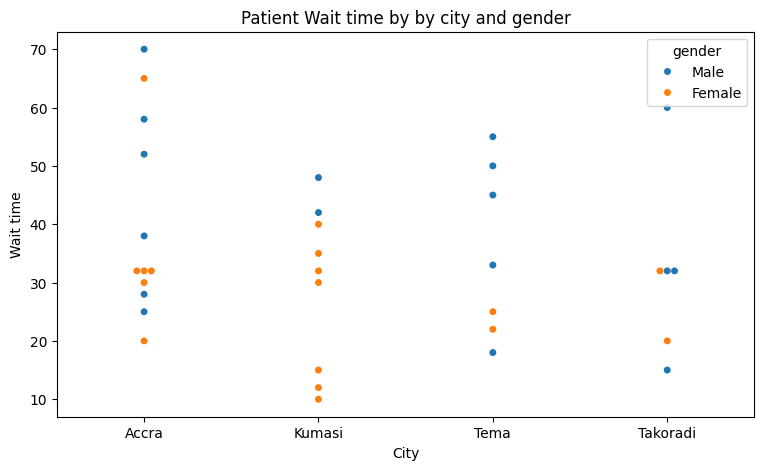

In [105]:
# Q6. Show the wait time of every individual patient grouped by city and separated by gender.
# Create either a strip plot or a swarm plot to display the individual data points.
plt.figure(figsize= (9,5))
sns.swarmplot(data=df, x="city", y="wait_time_min", hue="gender")
plt.title("Patient Wait time by by city and gender")
plt.xlabel("City")
plt.ylabel("Wait time")
plt.show()

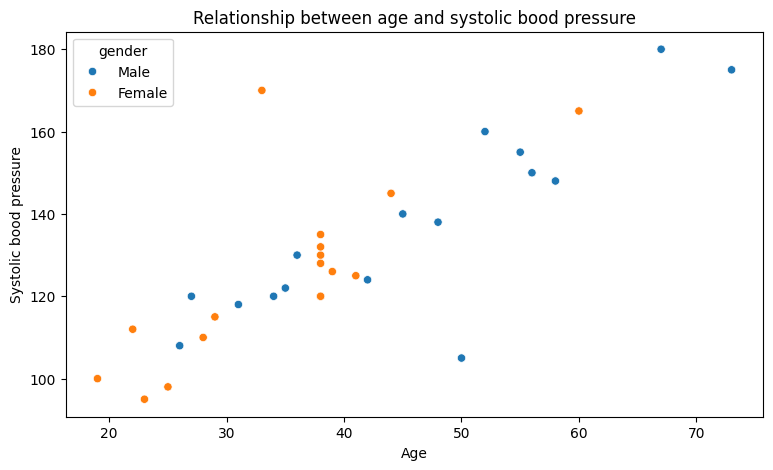

In [106]:
# Q7. Is there a relationship between patient age and systolic blood pressure?
# Create a scatter plot with points colored by gender.
plt.figure(figsize= (9,5))
sns.scatterplot(data=df, x="age", y="systolic", hue="gender")
plt.title("Relationship between age and systolic bood pressure")
plt.xlabel("Age")
plt.ylabel("Systolic bood pressure")
plt.show()

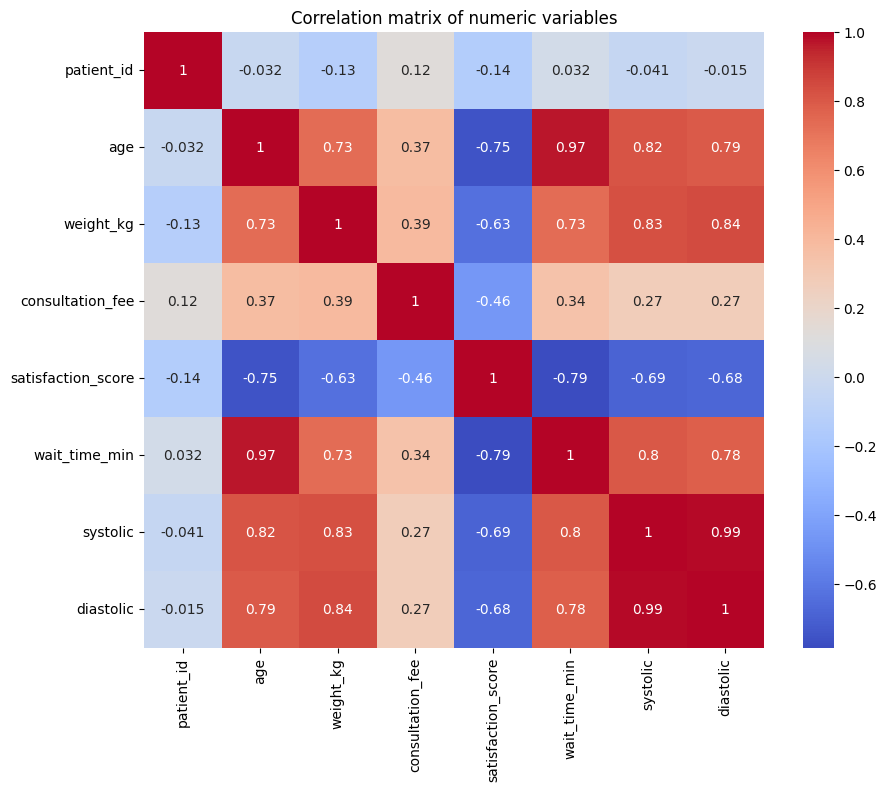

In [107]:
# Q8. Which numeric variables in the dataset have the strongest correlations with one another?
# Create a heatmap showing the correlation matrix of the numeric variables.
numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

# Heat plot
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation matrix of numeric variables")
plt.show()

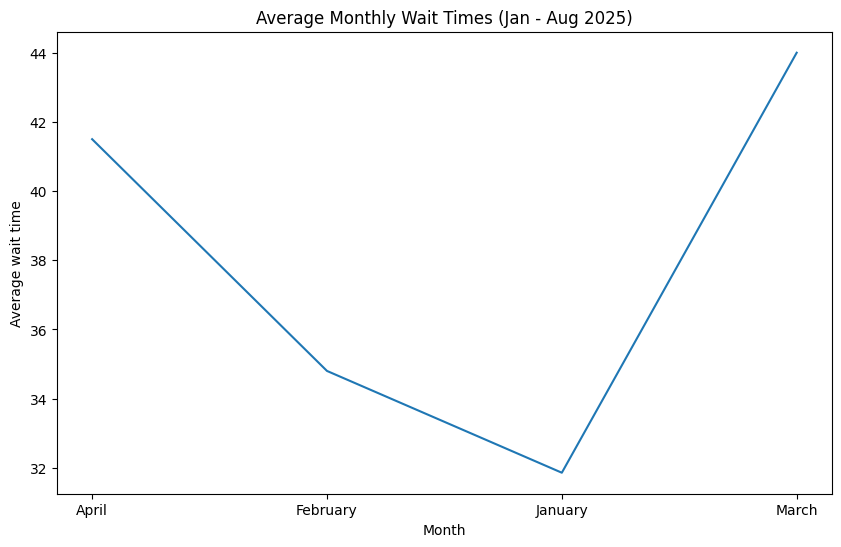

In [108]:
# Q9. How did average wait times change month by month from January to August 2025?
# Create a line plot to visualize the monthly trend in average wait times.
montly_wait = df.groupby("month")["wait_time_min"].mean().reset_index()

plt.figure(figsize= (10,6))
sns.lineplot(data=montly_wait, x="month", y="wait_time_min", markers="o")
plt.title("Average Monthly Wait Times (Jan - Aug 2025)")
plt.xlabel("Month")
plt.ylabel("Average wait time")
plt.show()

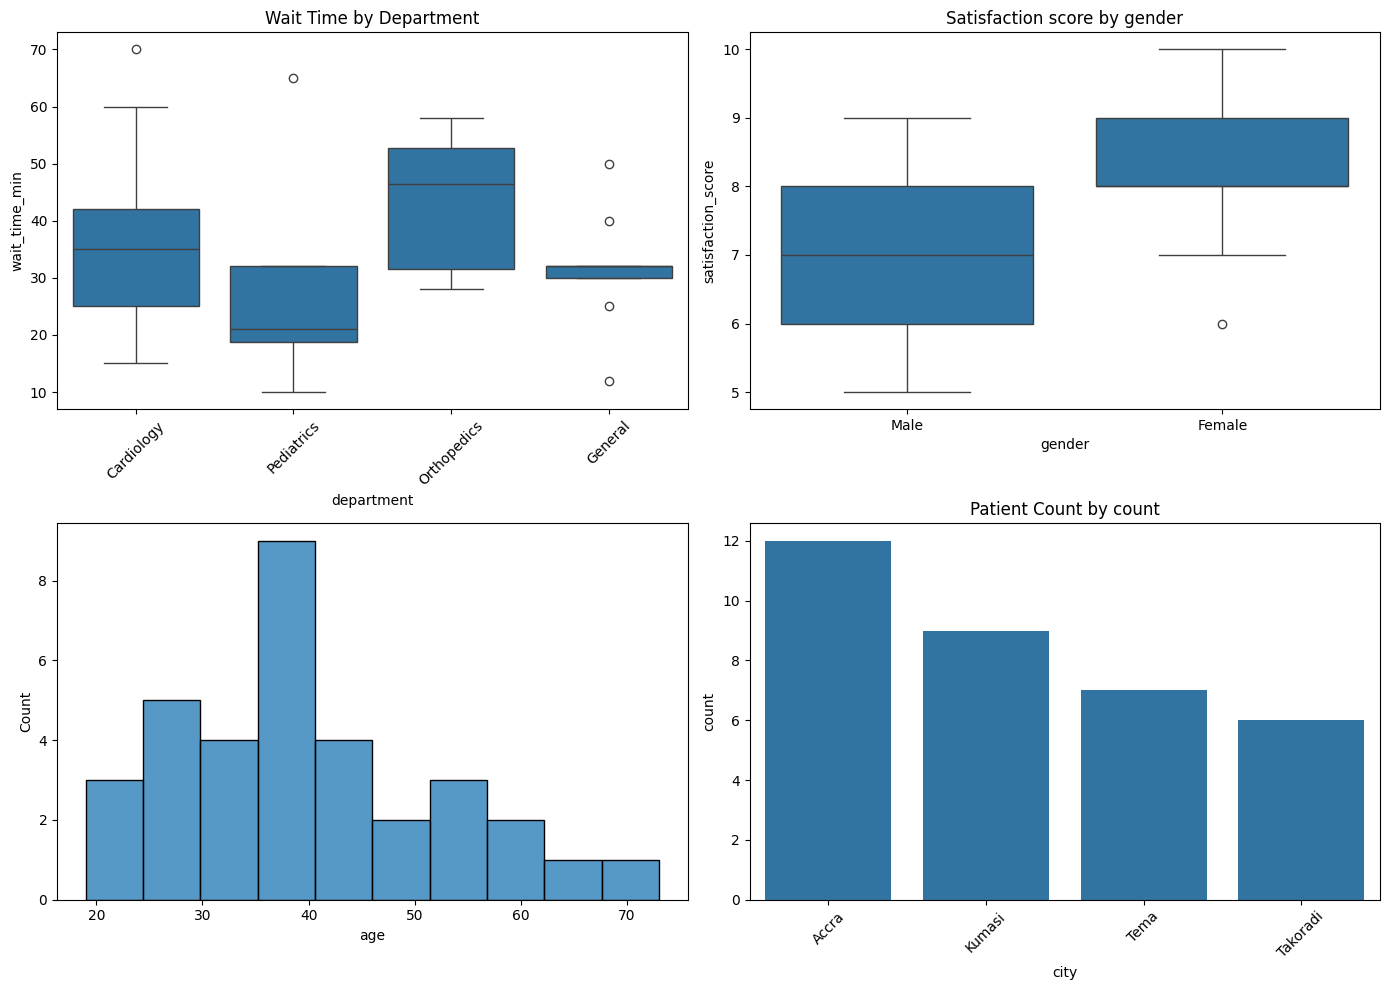

In [109]:
# Q10. Create a single figure containing four subplots that display the following:

# Wait time by department
# Satisfaction score by gender
# Age distribution
# Patient count by city
fig, axes = plt.subplots(2,2, figsize= (14,10))

sns.boxplot(data=df, x="department", y="wait_time_min", ax=axes[0, 0])
axes[0, 0].set_title("Wait Time by Department")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="gender", y="satisfaction_score", ax=axes[0, 1])
axes[0, 1].set_title("Satisfaction score by gender")

sns.histplot(data=df, x="age", bins=10, ax=axes[1, 0])

sns.countplot(data=df, x="city", ax=axes[1, 1])

axes[1, 1].set_title("Patient Count by count")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()